In [2]:
import kagglehub
import os
import nltk
from nltk.corpus import stopwords

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

### 1. Загрузка данных

In [5]:
path = kagglehub.dataset_download("ankurzing/sentiment-analysis-for-financial-news")
files = os.listdir(path)
print(files)

['all-data.csv', 'FinancialPhraseBank']


In [6]:
file_path = os.path.join(path, "all-data.csv")
df = pd.read_csv(file_path, header=None)
df = df.rename(columns={0: 'class', 1: 'text'})
df[:5]

,class,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


### 2. Анализ данных

#### 2.1 Определим пустые значения и множество категорий в столбце class

In [7]:
print(df.isna().sum())
print(df["class"].unique())

class    0
text     0
dtype: int64
['neutral' 'negative' 'positive']


#### 2.2 Изучим распределение классов

In [8]:
count_classes = []
count_classes.append(df["class"].where(df["class"] == "negative").count())
count_classes.append(df["class"].where(df["class"] == "neutral").count())
count_classes.append(df["class"].where(df["class"] == "positive").count())

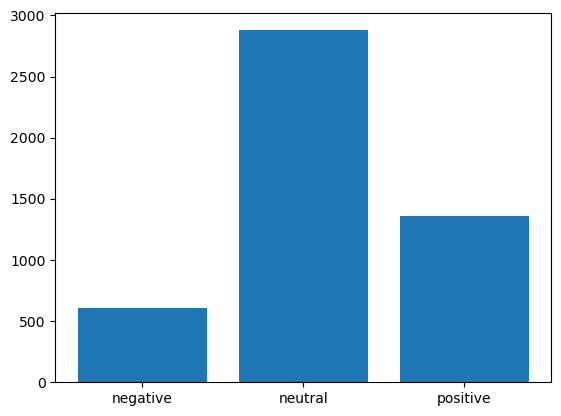

In [9]:
plt.bar(["negative", "neutral", "positive"], count_classes)
plt.show()

In [10]:
sum_total = sum(count_classes)
print("Доля каждого класса:")
print("Негативный:", round(count_classes[0]/sum_total * 100, 2), "%")
print("Нейтральный:", round(count_classes[1]/sum_total * 100, 2), "%")
print("Положительный:", round(count_classes[2]/sum_total * 100, 2), "%")

Доля каждого класса:
Негативный: 12.46 %
Нейтральный: 59.41 %
Положительный: 28.13 %


Как можно видеть из диаграммы, распределение классов неравномерное. В дальнейшем (при обучении модели) мы учтем этот дисбаланс классов, чтобы уменьшить влияние дисбаланса классов на обучение модели.

#### 2.3 Изучим распределение длины текста в зависимости от класса

In [11]:
import re

def remove_punctuation(text):
    return re.sub(r'[^a-zA-Z\s]', ' ', text)

def count_length(df):
    df = df.copy()
    df = df.apply(lambda x: remove_punctuation(x))
    return df.apply(lambda x: len(x.split()))    

In [12]:
df_new = df.where(df["class"] == "neutral").dropna()
words_neutral = count_length(df_new["text"])
df_new = df.where(df["class"] == "positive").dropna()
words_positive = count_length(df_new["text"])
df_new = df.where(df["class"] == "negative").dropna()
words_negative = count_length(df_new["text"])

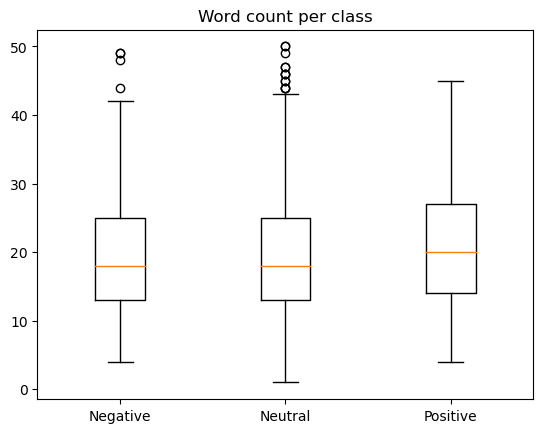

In [13]:
plt.boxplot([words_negative, words_neutral, words_positive], labels = ["Negative", "Neutral", "Positive"])
plt.title("Word count per class")
plt.show()

In [14]:
print(words_negative.describe())

count    604.000000
mean      19.599338
std        8.391641
min        4.000000
25%       13.000000
50%       18.000000
75%       25.000000
max       49.000000
Name: text, dtype: float64


In [260]:
print(words_neutral.describe())

count    2879.000000
mean       19.135116
std         8.473284
min         1.000000
25%        13.000000
50%        18.000000
75%        25.000000
max        50.000000
Name: text, dtype: float64


In [261]:
print(words_positive.describe())

count    1363.000000
mean       20.867205
std         8.524344
min         4.000000
25%        14.000000
50%        20.000000
75%        27.000000
max        45.000000
Name: text, dtype: float64


По полученным данным можно сделать вывод, что данные по каждому классу практически не различаются по длине. У всех классов средняя длина новости - 19-20 слов, практически одинаковое стандартное отклонение, практически одинаковые максимальные и минимальные значения.

#### 2.4 Определим самые часто встречающиеся слова

In [15]:
def prepare_text(df):
    df = df.copy()
    df["text"] = df["text"].apply(lambda x: remove_punctuation(x))
    df["text"] = df["text"].apply(lambda x: x.lower())
    return df

def count_words(df, cl):
    stop_words = stopwords.words("english")
    df = df.where(df["class"]==cl)["text"].dropna().copy()
    df = df.apply(lambda x: x.split())
    dict_freq = {}
    for idx, val in df.items():
        n = len(val)
        for i in range(n):
            if val[i] not in stop_words:
                if dict_freq.get(val[i]) is None:
                    dict_freq[val[i]]=1
                else:
                    dict_freq[val[i]]+=1
    dict_freq = sorted(dict_freq.items(), key=lambda x: x[1], reverse=True)
    return dict_freq

In [20]:
df = prepare_text(df)
dict_positive = count_words(df, "positive")
dict_neutral = count_words(df, "neutral")
dict_negative = count_words(df, "negative")
print(dict_positive[:20])
print("===")
print(dict_neutral[:20])
print("===")
print(dict_negative[:20])

[('eur', 639), ('mn', 264), ('company', 241), ('said', 230), ('year', 212), ('finnish', 202), ('net', 196), ('sales', 192), ('profit', 192), ('million', 170), ('period', 139), ('mln', 128), ('operating', 122), ('quarter', 114), ('oyj', 97), ('group', 97), ('rose', 94), ('increased', 89), ('new', 82), ('finland', 77)]
===
[('company', 510), ('eur', 359), ('said', 238), ('finland', 228), ('finnish', 220), ('business', 195), ('million', 193), ('group', 190), ('new', 189), ('sales', 165), ('shares', 163), ('services', 151), ('also', 145), ('share', 142), ('market', 136), ('net', 113), ('total', 100), ('helsinki', 99), ('mn', 98), ('mln', 95)]
===
[('eur', 417), ('mn', 237), ('profit', 156), ('net', 104), ('finnish', 102), ('company', 100), ('year', 100), ('sales', 98), ('operating', 97), ('period', 90), ('quarter', 89), ('million', 78), ('said', 77), ('loss', 69), ('compared', 68), ('decreased', 68), ('mln', 68), ('first', 59), ('oyj', 51), ('finland', 48)]


Несмотря на то, что мы не рассматривали самые популярные слова, во всех классах чаще всего встречаются однотипные слова. Такими словами является базовая финансовая лексика, но присутствуют также слова-маркеры, которые говорят о некоторой эмоциональной окраске. Например, таким является слово 'increased' в классе positive. 
Попробуем применить подход tf-idf, чтобы оценить, какие слова чаще всего встречаются во всех классах одновременно и какие слова потенциально могут стать шумом при классификации.

In [79]:
stop_words = stopwords.words("english")
vectorizer = TfidfVectorizer(stop_words=stop_words, min_df=5, max_df=0.8)
X = vectorizer.fit_transform(df["text"])

In [80]:
feature_names = vectorizer.get_feature_names_out()
tfidf_sorted = np.asarray(X.mean(axis=0)).ravel()
idx = np.argsort(-tfidf_sorted)

In [81]:
print(feature_names[idx[:30]])
print(feature_names[idx[-30:]])

['eur' 'mn' 'company' 'sales' 'million' 'profit' 'said' 'net' 'year'
 'finnish' 'operating' 'finland' 'group' 'period' 'mln' 'share' 'new'
 'quarter' 'also' 'business' 'market' 'shares' 'first' 'services'
 'compared' 'oyj' 'loss' 'euro' 'contract' 'per']
['unnamed' 'royal' 'fields' 'email' 'esl' 'log' 'spain' 'note' 'wholly'
 'tvs' 'saint' 'diagnostic' 'yhtyma' 'wet' 'animal' 'osl' 'principal'
 'sells' 'elektrobit' 'tamglass' 'distributed' 'nda' 'suite' 'convergent'
 'asa' 'morvillars' 'loudeac' 'marcel' 'dedicated' 'brief']


Сверху приведено 20 слов, которые с точки зрения tf-idf считаются самыми значимыми. Снизу приведены 20 слов, которые считаются наименее значимыми с точки зрения метрики tf-idf. Вероятно, слова с низким значением метрики являются скорее редко использующимися, чем активно повторяющимися. 